In [1]:
import pandas as pd

# 결정트리 depth 차이가 잘 보이도록 만든 데이터
# 특징:
# - 일부 구간은 규칙이 명확함
# - 일부 구간은 의도적으로 섞어서 불순도 증가
# - depth가 깊어질수록 train 성능은 올라가지만
#   test 성능은 과적합으로 흔들리게 설계

data = {
    "연소득(백만)": [
        25,27,29,30,31,32,33,34,35,36,
        37,38,39,40,41,42,43,44,45,46,
        47,48,49,50,51,52,53,54,55,56,
        57,58,59,60,61,62,63,64,65,66,
        67,68,69,70,71,72,73,74,75,76,
        77,78,79,80,81,82,83,84,85,86,
        87,88,89,90,91,92,93,94,95,96,
        97,98,99,100,101,102,103,104,105,106,
        107,108,109,110,111,112,113,114,115,116,
        117,118,119,120,121,122,123,124,125,126,

        25,28,31,34,37,40,43,46,49,52,
        55,58,61,64,67,70,73,76,79,82,
        85,88,91,94,97,100,103,106,109,112,
        115,118,121,124,127,130,133,136,139,142,

        26,29,32,35,38,41,44,47,50,53,
        56,59,62,65,68,71,74,77,80,83,
        86,89,92,95,98,101,104,107,110,113,
        116,119,122,125,128,131,134,137,140,143,

        27,30,33,36,39,42,45,48,51,54,
        57,60,63,66,69,72,75,78,81,84,
        87,90,93,96,99,102,105,108,111,114,
        117,120,123,126,129,132,135,138,141,144
    ],

    "신용점수": [
        580,590,600,610,620,630,640,650,660,670,
        680,690,700,710,720,730,740,750,760,770,
        580,590,600,610,620,630,640,650,660,670,
        680,690,700,710,720,730,740,750,760,770,
        580,590,600,610,620,630,640,650,660,670,
        680,690,700,710,720,730,740,750,760,770,
        580,590,600,610,620,630,640,650,660,670,
        680,690,700,710,720,730,740,750,760,770,
        580,590,600,610,620,630,640,650,660,670,
        680,690,700,710,720,730,740,750,760,770,

        600,610,620,630,640,650,660,670,680,690,
        700,710,720,730,740,750,760,770,780,790,
        600,610,620,630,640,650,660,670,680,690,
        700,710,720,730,740,750,760,770,780,790,

        590,600,610,620,630,640,650,660,670,680,
        690,700,710,720,730,740,750,760,770,780,
        590,600,610,620,630,640,650,660,670,680,
        690,700,710,720,730,740,750,760,770,780,

        585,595,605,615,625,635,645,655,665,675,
        685,695,705,715,725,735,745,755,765,775,
        585,595,605,615,625,635,645,655,665,675,
        685,695,705,715,725,735,745,755,765,775
    ],

    "부채비율(%)": [
        55,54,53,52,51,50,49,48,47,46,
        45,44,43,42,41,40,39,38,37,36,
        35,34,33,32,31,30,29,28,27,26,
        25,24,23,22,21,20,19,18,17,16,
        15,14,13,12,11,10,9,8,7,6,
        5,4,3,2,1,5,10,15,20,25,
        30,35,40,45,50,55,12,14,16,18,
        20,22,24,26,28,30,32,34,36,38,
        40,42,44,46,48,50,52,54,56,58,
        60,25,20,15,10,5,8,12,18,22,

        45,40,35,30,25,20,15,10,5,8,
        12,16,20,24,28,32,36,40,44,48,
        52,56,60,18,22,26,30,34,38,42,
        46,50,54,58,12,16,20,24,28,32,

        50,45,40,35,30,25,20,15,10,5,
        8,12,16,20,24,28,32,36,40,44,
        48,52,56,60,18,22,26,30,34,38,
        42,46,50,54,58,12,16,20,24,28,

        55,50,45,40,35,30,25,20,15,10,
        5,8,12,16,20,24,28,32,36,40,
        44,48,52,56,60,18,22,26,30,34,
        38,42,46,50,54,58,12,16,20,24
    ]
}

df = pd.DataFrame(data)
df['연소득(백만)'] = df['연소득(백만)'].astype(float)

# 승인 규칙 생성
# 일부 노이즈 추가해서 depth 차이가 확실히 나도록 구성
df["대출승인"] = (
    (
        (df["연소득(백만)"] >= 60) &
        (df["신용점수"] >= 680) &
        (df["부채비율(%)"] <= 35)
    )
).astype(int)

# 의도적 노이즈 추가 (과적합 유도)
noise_index = [
    5, 12, 19, 28, 35, 41, 50, 63, 72, 84,
    91, 103, 117, 126, 138, 149, 158, 166, 177, 188
]

df.loc[noise_index, "대출승인"] = 1 - df.loc[noise_index, "대출승인"]

print(df.head())
print(df.shape)

   연소득(백만)  신용점수  부채비율(%)  대출승인
0     25.0   580       55     0
1     27.0   590       54     0
2     29.0   600       53     0
3     30.0   610       52     0
4     31.0   620       51     0
(220, 4)


In [5]:
from sklearn.model_selection import train_test_split
# X, y 선택하고 데이터셋 나누기
X = df[['연소득(백만)', '신용점수', '부채비율(%)']]
print(X.shape)
y = df['대출승인']
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

(220, 3)
(220,)


In [6]:
# 위쪽 트리가 한쪽으로 치우쳤다 결론을 내려봤다 -test-

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier( #파라미터..
        #트리의 최대 깊이, 중요한 파라미터
        #피처와 샘플데이터에 비해서 너무 깊으면 과적합
        #3개부터 10까지 조절하면서 ..
        max_depth = 3,
        #리프노드가 가져야 하는 최소 샘플 수 *중요한 파라미터
        #샘플 데이터가 많으면 5부터 차례대로 합니다
        min_samples_leaf = 5, # 5개의 샘플로 분류, 회귀 결과값
        
        # 불순도 계산 방식 - 노드에 샘플[승인4, 비승인8]
        criterion = 'gini',
        class_weight = 'balanced' # 학습데이터가 정규분포형태라면 좋음
        )

In [7]:
clf = model.fit(X_train, y_train)

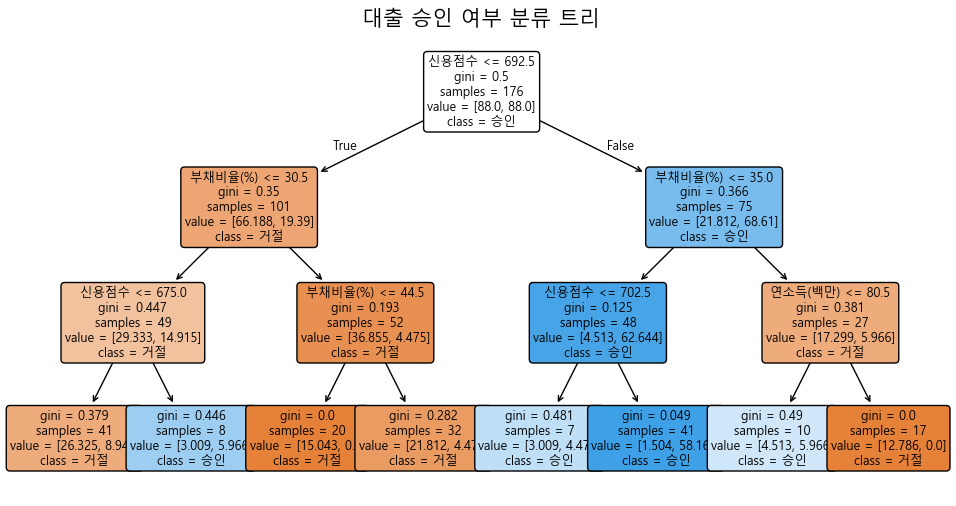

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 1. 분류 모델 시각화
plt.figure(figsize=(12, 6))  # 크기를 15,10에서 10,6으로 줄임
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['거절', '승인'], 
          filled=True, 
          rounded=True, 
          fontsize=9)  # 글자 크기를 조절하여 가독성 향상
plt.title("대출 승인 여부 분류 트리", fontsize=15)
plt.show()

c:\Users\human-03\Desktop\AI\DECISIONTREE\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\human-03\Desktop\AI\DECISIONTREE\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


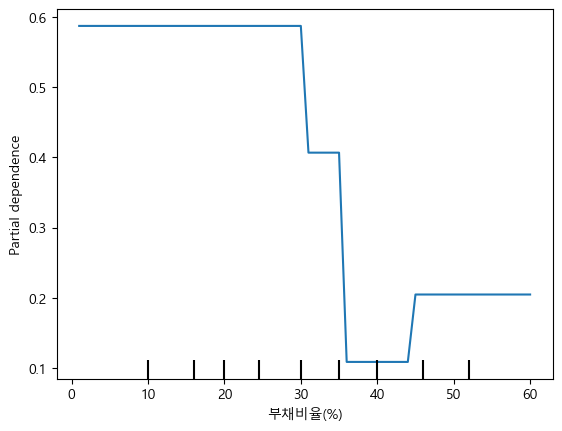

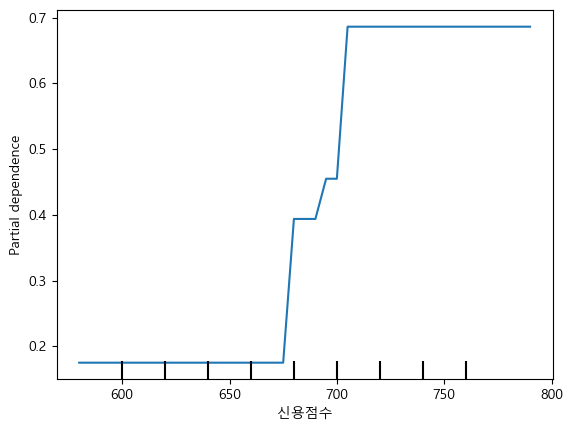

In [10]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(model, X, ['부채비율(%)'])
PartialDependenceDisplay.from_estimator(model, X, ['신용점수'])

In [13]:
# 예시: 소득 50, 신용 650, 부채 1인 사람
new_customer = pd.DataFrame([[100, 1000, 9]], columns=X.columns)
result = clf.predict(new_customer)
print(f"새로운 고객 승인 여부: {'승인' if result[0] == 1 else '거절'}")

import pandas as pd

importances = pd.Series(clf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

새로운 고객 승인 여부: 승인
신용점수       0.566709
부채비율(%)    0.360860
연소득(백만)    0.072431
dtype: float64
